## **6. Prov-GigaPath - Transfer learning**

In this notebook we report the usage of **Prov-GigaPath**, a pretrained transformer architecture designed to handle pathology images. In particular, in this last experiment, GigaPath is used exclusively as image encoder/feature extractor (no fine tuning) for the **224x224-sized patches** extracted from the original WSI images. The model includes an **Attention-based MIL (Multiple Instance Learning)** layer, that aggregates patch embeddings refering to the same WSI image, plus an MLP classifier to generate WSI-level predictions.

## 🌐 **Google Drive Connection**

In [ ]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My\\ Drive/challenge2AN2DL"
%cd $current_dir

Mounted at /gdrive
/gdrive/.shortcut-targets-by-id/1sSQJKU_eQUTptnQou58Hgxaj8RPPeM6b/challenge2AN2DL


## ⚙️ **Libraries Import**

In [ ]:
# HuggingFace Login

from huggingface_hub import login, whoami

# Paste here a READ token that has access to the prov-gigapath repository
HF_TOKEN = "xxxx"

login(token=HF_TOKEN)
print("Logged in to Hugging Face as:", whoami()["name"])

In [ ]:
# Suppress warnings
import warnings
# Hide warnings to keep notebook output readable (useful during experiments).
warnings.simplefilter(action='ignore', category=FutureWarning)
# Hide warnings to keep notebook output readable (useful during experiments).
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
from glob import glob

# Set seed for reproducibility
SEED = 436346
np.random.seed(SEED)
random.seed(SEED)

# Import necessary libraries
import os

# Make Python's hashing deterministic (affects iteration order in some hashed containers)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader, Dataset

# Tensorboard and directory configuration
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import pickle
from collections import OrderedDict
from tqdm import tqdm
import copy
import shutil
from itertools import product
from sklearn.metrics import f1_score
from copy import deepcopy
import math
from sklearn.model_selection import StratifiedGroupKFold
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import pickle
import matplotlib.gridspec as gridspec
from concurrent.futures import ThreadPoolExecutor
import timm
from collections import defaultdict
import torch.nn as nn
!pip install ranger-adabelief
from ranger_adabelief import RangerAdaBelief

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

## ⏳ **Data Loading**

In [ ]:
# train_data_dictionary = { "img_XXXX.png" : (224,224,3) }, where:
#   - XXXX is the zero-padded patch index
#   - (224,224,3) is a 3D matrix describing the patch
#   - pixel values are already between 0 and 1
dict_path = "dataset/patches_224/train_data_dictionary.pkl"

with open(dict_path, "rb") as f:
    X_train_val_dict = pickle.load(f)

print("Train data dictionary loaded! Number of images: ", len(X_train_val_dict))
print("Examples of image names: ", list(X_train_val_dict.keys())[:5])

# "cleaned_patched_train_labels.csv" is a csv file with the following columns:
#   - "index" -> patch index
#   - "label" -> label of the WSI from which the patch was extracted
#   - "original_idx" -> index of the WSI from which the patch was extracted
y_train_val_df = pd.read_csv("dataset/patches_224/cleaned_patched_train_labels.csv")
y_train_val_df['index'] = y_train_val_df['index'].astype(int)
y_train_val_df['filename'] = y_train_val_df['index'].apply(lambda x: f"img_{x:04d}.png")

unique_labels = sorted(y_train_val_df['label'].unique().tolist())
print("Train labels loaded! Unique labels: ", unique_labels)
print("Number of original images: ", y_train_val_df['original_idx'].nunique())

Train data dictionary loaded! Number of images:  2763
Examples of image names:  ['img_0001.png', 'img_0002.png', 'img_0003.png', 'img_0004.png', 'img_0005.png']
Train labels loaded! Unique labels:  ['HER2(+)', 'Luminal A', 'Luminal B', 'Triple negative']
Number of original images:  581


In [ ]:
# Imagenet normalization statistics
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Define patch transformations
feat_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Custom PyTorch Dataset with optional normalization
class PatchDictDataset(Dataset):
    def __init__(self, X_dict, filenames, transform):
        self.X_dict = X_dict
        self.filenames = list(filenames)
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fn = self.filenames[idx]
        img = self.X_dict[fn]  # np.float32 HWC in [0,1]
        x = self.transform(img)
        return fn, x

## 🛠️ **Feature Extraction**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Wrap the pretrained 'prov-gigapath' model so we can easily extract embeddings for patches
class GigaPathEncoder(nn.Module):
    def __init__(self, model_name="hf_hub:prov-gigapath/prov-gigapath"):
        super().__init__()

        self.model = timm.create_model(model_name, pretrained=True)
        self.model.eval()

        for p in self.model.parameters():
            # Freeze encoder weights: we only use it for feature extraction, not fine-tuning
            p.requires_grad = False

        self.out_dim = getattr(self.model, "num_features", None)

    @torch.no_grad()
    # Forward pass for feature generation
    def forward(self, x):
        if hasattr(self.model, "forward_features"):
            feat = self.model.forward_features(x)
            if feat.dim() == 3:
                feat = feat[:, 0]  # CLS token
            return feat
        return self.model(x)

# Create the encoder
encoder = GigaPathEncoder().to(device)
print("GigaPath embedding dim:", encoder.out_dim)


GigaPath embedding dim: 1536


In [ ]:
# List of all patch file names
all_filenames = y_train_val_df["filename"].tolist()

# Create patch dataset
ds = PatchDictDataset(X_train_val_dict, all_filenames, feat_transform)

# Create patch data loader
loader = DataLoader(
    ds,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Set the encoder in evaluation mode (we just use it as feature extractor)
encoder.eval()

# Extract features from patches
emb_dict = {}
with torch.no_grad():
    for fns, xb in tqdm(loader, desc="Extracting GigaPath features"):
        xb = xb.to(device, non_blocking=True)
        feats = encoder(xb).detach().cpu().numpy().astype(np.float32)  # (B, D)
        for fn, vec in zip(fns, feats):
            emb_dict[fn] = vec

# Sort by filename to make the dictionary deterministic/ordered
emb_dict_sorted = OrderedDict(sorted(emb_dict.items(), key=lambda kv: kv[0]))

# Save features in a dictionary
out_path = "dataset/patches_444/gigapath_features_sorted.pkl"
with open(out_path, "wb") as f:
    pickle.dump(emb_dict_sorted, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Saved:", out_path, "| n_patches:", len(emb_dict_sorted))

Extracting GigaPath features: 100%|██████████| 22/22 [01:11<00:00,  3.24s/it]


Saved: dataset/patches_444/gigapath_features_sorted.pkl | n_patches: 2763


## 🛠️ **Feature Processing**

In [ ]:
# Load feature dictionary
with open("dataset/patches_444/gigapath_features_sorted.pkl", "rb") as f:
    emb_dict_sorted = pickle.load(f)

# Map the categorical labels to numerical values
label_mapping = {
    "HER2(+)": 0,
    "Luminal A": 1,
    "Luminal B": 2,
    "Triple negative": 3
}
df_feat = y_train_val_df.copy()
df_feat["y"] = df_feat["label"].map(label_mapping)

# Build the array of training-validation features, by following che patch order specified in the "y_train_val_df" dataframe
X = np.stack([emb_dict_sorted[fn] for fn in df_feat["filename"].values], axis=0).astype(np.float32)
y = df_feat["y"].values.astype(np.int64)

# Group by original WSI index
groups = df_feat["original_idx"].values

print("X shape:", X.shape, "y shape:", y.shape, "n_groups:", len(np.unique(groups)))

X shape: (2763, 1536) y shape: (2763,) n_groups: 581


In [ ]:
# Perform stratified splitting between training and validation original WSI indices
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(X, y, groups))

print("Num train patches:", len(train_idx), "| Num val patches:", len(val_idx))
print("WSI leakage check (should be 0):",
      len(set(groups[train_idx]).intersection(set(groups[val_idx]))))

Num train patches: 2182 | Num val patches: 581
WSI leakage check (should be 0): 0


In [ ]:
# Split the dataframe according to the train-validation split
train_groups = df_feat.iloc[train_idx]["original_idx"].values
val_groups   = df_feat.iloc[val_idx]["original_idx"].values

# Training and validation WSI indices
train_wsi_ids = np.unique(train_groups)
val_wsi_ids   = np.unique(val_groups)

print("Train WSI:", len(train_wsi_ids), "Val WSI:", len(val_wsi_ids))
print("WSI leakage:", len(set(train_wsi_ids).intersection(set(val_wsi_ids))))

# This function creates associations between WSI indices and the corresponding patch filenames
def build_wsi_to_filenames(df_subset):
    d = defaultdict(list)
    for gid, fn in zip(df_subset["original_idx"].values, df_subset["filename"].values):
        d[int(gid)].append(fn)
    return d

# Training and validation dataframes
df_train = df_feat.iloc[train_idx].reset_index(drop=True)
df_val   = df_feat.iloc[val_idx].reset_index(drop=True)

# Create WSI-patch associations
train_wsi_to_fns = build_wsi_to_filenames(df_train)
val_wsi_to_fns   = build_wsi_to_filenames(df_val)

def wsi_label(df_subset, gid):
    ys = df_subset.loc[df_subset["original_idx"] == gid, "y"].unique()
    assert len(ys) == 1, f"WSI {gid} has multiple labels: {ys}"
    return int(ys[0])

Train WSI: 465 Val WSI: 116
WSI leakage: 0


## 🧠 **Model Training**

In [ ]:
# Dataset that returns a "bag" (collection) of patch embeddings for a WSI + the WSI label
class WSIBagEmbDataset(Dataset):
    def __init__(self, wsi_ids, wsi_to_fns, df_subset, emb_dict):
        self.wsi_ids = list(wsi_ids)
        self.wsi_to_fns = wsi_to_fns
        self.df = df_subset
        self.emb = emb_dict

    def __len__(self):
        return len(self.wsi_ids)

    def __getitem__(self, idx):
        gid = int(self.wsi_ids[idx])
        fns = self.wsi_to_fns[gid]
        P = np.stack([self.emb[fn] for fn in fns], axis=0).astype(np.float32)  # (N, D)
        y = wsi_label(self.df, gid)
        return torch.from_numpy(P), torch.tensor(y, dtype=torch.long)

# Define the MIL classifier
class AttentionPoolClassifier(nn.Module):
    """
    Input: bag of patch embeddings P with shape (N, D)
    Output: logits for WSI class with shape (C,)
    """
    def __init__(self, in_dim, num_classes=4, att_dim=64, hidden=256, dropout=0.4):
        super().__init__()
        # Attention-based MIL layer
        self.att = nn.Sequential(
            nn.Linear(in_dim, att_dim),
            nn.Tanh(),
            nn.Linear(att_dim, 1)
        )
        # MLP classification head
        self.head = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, P):
        # The patch features belogning to a bag go through the attention layer
        a = self.att(P).squeeze(-1)
        # Temperature parameter to avoid overly peaky attention weights
        TEMP = 1.5343502788558907
        w = torch.softmax(a / TEMP, dim=0).unsqueeze(-1)
        # Perform weighted sum of patch embeddings using weights computed by the attention layer
        z = (w * P).sum(dim=0)
        # The final embedding goes through the classification head
        return self.head(z.unsqueeze(0)).squeeze(0)  # (C,)

In [ ]:
# Build training and validation bag datasets
train_ds = WSIBagEmbDataset(train_wsi_ids, train_wsi_to_fns, df_train, emb_dict_sorted)
val_ds   = WSIBagEmbDataset(val_wsi_ids,   val_wsi_to_fns,   df_val,   emb_dict_sorted)

# Build training and validation data loaders
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=1, shuffle=False)

In [ ]:
# Infer embedding dim
P0, _ = train_ds[0]
in_dim = P0.shape[1]
print("Embedding dim:", in_dim)

# Create classification model
model = AttentionPoolClassifier(in_dim=in_dim, num_classes=4, att_dim=256, hidden=64, dropout=0.1320151489603946).to(device) # was att dim 256, hidden 512

# Optimizer (RangerAdaBelief combines RAdam + LookAhead with AdaBelief-style variance adaptation)
optimizer = RangerAdaBelief(model.parameters(), lr=0.0005679438147713504, weight_decay=0.00016859466779156176)

# Define number of classes
num_classes = 4

# Define cross-entropy loss
y_train_wsi = np.array(
    [int(df_train.loc[df_train["original_idx"] == gid, "y"].iloc[0]) for gid in train_wsi_ids],
    dtype=np.int64
)
counts = np.bincount(y_train_wsi, minlength=num_classes).astype(np.float32)
weights = counts.sum() / (num_classes * np.maximum(counts, 1.0))
weights = torch.tensor(weights, dtype=torch.float32, device=device)
print("Train WSI class counts:", counts)
print("Class weights:", weights.detach().cpu().numpy())
criterion = nn.CrossEntropyLoss(weight=weights)

Embedding dim: 1536
Ranger optimizer loaded. 
Gradient Centralization usage = True
GC applied to both conv and fc layers
Train WSI class counts: [116. 124. 165.  60.]
Class weights: [1.0021552  0.9375     0.70454544 1.9375    ]


In [ ]:
# This function runs the model over the training or validation set (depending on the optimizer parameter)
def run_one_epoch_attention(model, loader, criterion, optimizer=None):
    # Decide between training and validation
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []

    for P, y in loader:
        P = P.squeeze(0).to(device)        # (N, D)
        y = y.to(device).squeeze(0)        # ()
        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            # Froward pass
            logits = model(P)              # (C,)
            loss = criterion(logits.unsqueeze(0), y.unsqueeze(0))
            if is_train:
                # Backward pass
                loss.backward()
                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

        # Accumulate metrics
        total_loss += loss.item()
        pred = int(logits.argmax().detach().cpu().item())
        all_preds.append(pred)
        all_targets.append(int(y.detach().cpu().item()))

    # Calculate epoch metrics
    avg_loss = total_loss / max(1, len(loader))
    f1 = f1_score(np.array(all_targets), np.array(all_preds), average="weighted")
    return avg_loss, f1

In [ ]:
# This function performs model training, reporting the history of cross-entropy loss and weighted F1 score on training and validaton
#     sets, epoch by epoch

def fit_attention(model, train_loader, val_loader, optimizer, criterion, epochs=100, patience=15):
    best_state = deepcopy(model.state_dict())
    best_val_f1 = -math.inf
    no_improve = 0

    history = {"train_loss": [], "train_f1": [], "val_loss": [], "val_f1": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_f1 = run_one_epoch_attention(model, train_loader, criterion, optimizer)
        va_loss, va_f1 = run_one_epoch_attention(model, val_loader,   criterion, optimizer=None)

        history["train_loss"].append(tr_loss)
        history["train_f1"].append(tr_f1)
        history["val_loss"].append(va_loss)
        history["val_f1"].append(va_f1)

        print(
            f"Epoch {epoch:03d}/{epochs} | "
            f"Train: loss={tr_loss:.4f}, f1={tr_f1:.4f} | "
            f"Val: loss={va_loss:.4f}, f1={va_f1:.4f}"
        )

        if va_f1 > best_val_f1:
            best_val_f1 = va_f1
            best_state = deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch} (best Val F1={best_val_f1:.4f})")
                break

    model.load_state_dict(best_state)
    return model, history

# Perform model training
best_model, history = fit_attention(
    model, train_loader, val_loader,
    optimizer=optimizer, criterion=criterion,
    epochs=300, patience=20
)

Epoch 001/300 | Train: loss=1.3542, f1=0.2002 | Val: loss=1.3123, f1=0.1692
Epoch 002/300 | Train: loss=1.3352, f1=0.2385 | Val: loss=1.3107, f1=0.1692
Epoch 003/300 | Train: loss=1.3418, f1=0.2132 | Val: loss=1.2709, f1=0.2776
Epoch 004/300 | Train: loss=1.3092, f1=0.3113 | Val: loss=1.2611, f1=0.1933
Epoch 005/300 | Train: loss=1.2862, f1=0.3430 | Val: loss=1.2800, f1=0.2833
Epoch 006/300 | Train: loss=1.2655, f1=0.3370 | Val: loss=1.2614, f1=0.2826
Epoch 007/300 | Train: loss=1.2432, f1=0.3844 | Val: loss=1.2547, f1=0.3059
Epoch 008/300 | Train: loss=1.2415, f1=0.4068 | Val: loss=1.2464, f1=0.3955
Epoch 009/300 | Train: loss=1.2661, f1=0.4077 | Val: loss=1.2111, f1=0.4136
Epoch 010/300 | Train: loss=1.2208, f1=0.4143 | Val: loss=1.2610, f1=0.3717
Epoch 011/300 | Train: loss=1.2557, f1=0.4408 | Val: loss=1.2459, f1=0.4379
Epoch 012/300 | Train: loss=1.1842, f1=0.4659 | Val: loss=1.2679, f1=0.4202
Epoch 013/300 | Train: loss=1.2312, f1=0.4563 | Val: loss=1.2517, f1=0.4023
Epoch 014/30

In [ ]:
# Save trained model
os.makedirs("models", exist_ok=True)

BEST_CKPT_PATH = f"models/gigapath_attention_pool_seed{SEED}.pt"

torch.save(best_model.state_dict(), BEST_CKPT_PATH)
print("Saved BEST checkpoint:", BEST_CKPT_PATH)

Saved BEST checkpoint: models/gigapath_attention_pool_seed436346.pt


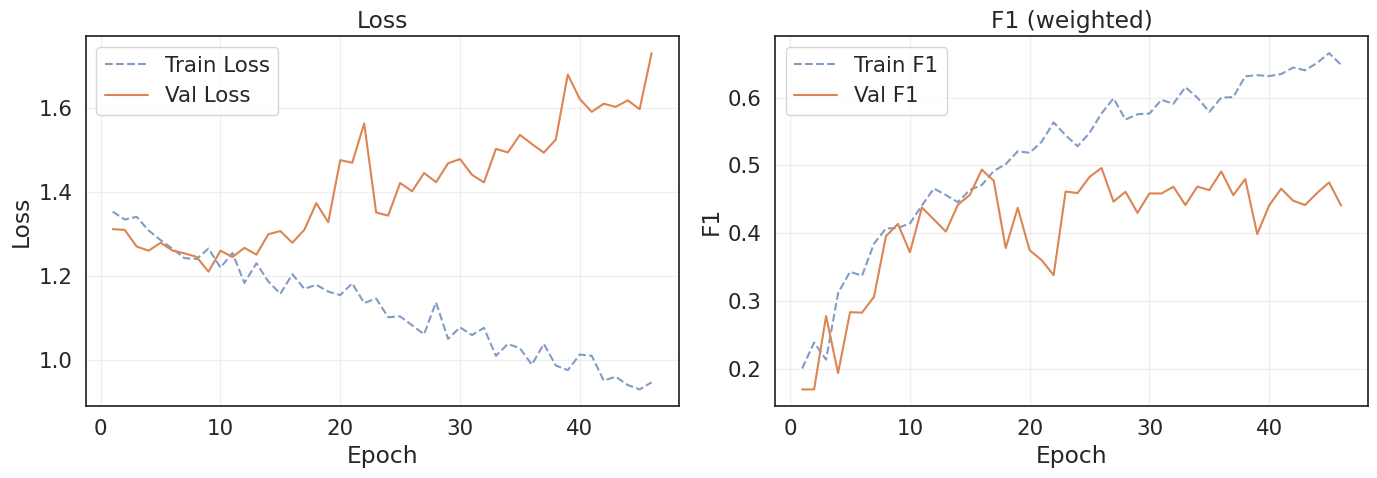

In [ ]:
# @title Plot History
# Plot training and validation loss and F1 curves from the training history

import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---- Loss ----
ax1.plot(epochs, history["train_loss"], label="Train Loss", linestyle="--", alpha=0.7)
ax1.plot(epochs, history["val_loss"],   label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

# ---- F1 ----
ax2.plot(epochs, history["train_f1"], label="Train F1", linestyle="--", alpha=0.7)
ax2.plot(epochs, history["val_f1"],   label="Val F1")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1")
ax2.set_title("F1 (weighted)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 🧠 **Inference**


In [ ]:
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Load pre-generated embeddings for test patches
FEAT_PATH = "giga_inference/outputs/test_patch_features.pt"
blob = torch.load(FEAT_PATH, map_location="cpu", weights_only=False)
emb_test = blob["embeddings"]
patch_to_wsi = blob["patch_to_wsi"]
print("Loaded patch features:", len(emb_test), "| from:", FEAT_PATH)

Loaded patch features: 2285 | from: giga_inference/outputs/test_patch_features.pt


In [ ]:
assert "BEST_CKPT_PATH" in globals(), "BEST_CKPT_PATH not found. Run the 'SAVE BEST MODEL' cell first."
assert os.path.exists(BEST_CKPT_PATH), f"Checkpoint not found: {BEST_CKPT_PATH}"

# Create classification model
in_dim = len(next(iter(emb_test.values())))
mil_model = AttentionPoolClassifier(in_dim=in_dim, num_classes=4, att_dim=256, hidden=64, dropout=0.1320151489603946).to(device)

# Load weights from the previously trained model
state = torch.load(BEST_CKPT_PATH, map_location=device)
mil_model.load_state_dict(state)

# Model used for evaluation
mil_model.eval()

AttentionPoolClassifier(
  (att): Sequential(
    (0): Linear(in_features=1536, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
  (head): Sequential(
    (0): Linear(in_features=1536, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.1320151489603946, inplace=False)
    (3): Linear(in_features=64, out_features=4, bias=True)
  )
)

In [ ]:
# Group patch indices per WSI
wsi_to_fns = defaultdict(list)
for fn, gid in patch_to_wsi.items():
    wsi_to_fns[int(gid)].append(fn)
wsi_ids = sorted(wsi_to_fns.keys())
print("WSI to infer:", len(wsi_ids))

WSI to infer: 477


In [ ]:
# Set Temperature parameter for attention layer
TEMP = 1.5343502788558907

# This function generates the softmax probabilities for a WSI (processing a bag of patch embeddings)
@torch.no_grad()
def forward_wsi_with_attention(model, P, temp=5.0):
    a = model.att(P).squeeze(-1)            # (N,)
    w = torch.softmax(a / temp, dim=0)      # (N,)
    z = (w.unsqueeze(-1) * P).sum(dim=0)    # (D,)
    logits = model.head(z.unsqueeze(0)).squeeze(0)  # (C,)
    return logits, w

# Perform inference over the test set
rows = []
for gid in tqdm(wsi_ids, desc="WSI inference"):
    fns = sorted(wsi_to_fns[gid])
    P = np.stack([emb_test[fn] for fn in fns], axis=0).astype(np.float32)
    P = torch.from_numpy(P).to(device)

    logits, _ = forward_wsi_with_attention(mil_model, P, temp=TEMP)
    probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
    pred = int(np.argmax(probs))

    rows.append({
        "original_idx": gid,
        "num_patches": len(fns),
        "pred_class": pred,
        "prob_0": float(probs[0]),
        "prob_1": float(probs[1]),
        "prob_2": float(probs[2]),
        "prob_3": float(probs[3]),
    })

WSI inference: 100%|██████████| 477/477 [00:00<00:00, 1842.73it/s]


In [ ]:
# Save predictions csv
df_wsi_pred = pd.DataFrame(rows).sort_values("original_idx").reset_index(drop=True)
PRED_PATH = os.path.join(OUT_DIR, f"test_wsi_predictions_seed{SEED}.csv")
df_wsi_pred.to_csv(PRED_PATH, index=False)
print("Saved WSI predictions:", PRED_PATH)

Saved WSI predictions: outputs/test_wsi_predictions_seed436346.csv


In [ ]:
# Load predictions csv
df = pd.read_csv(PRED_PATH)

# Inverse label mapping for submission csv file
label_map = {
    0: "HER2(+)",
    1: "Luminal A",
    2: "Luminal B",
    3: "Triple negative"
}

# Submission csv generation
sub = pd.DataFrame({
    "sample_index": df["original_idx"].apply(lambda x: f"img_{int(x):04d}.png"),
    "label": df["pred_class"].map(label_map)
})

SUB_PATH = os.path.join(OUT_DIR, f"last_submission.csv")
sub.to_csv(SUB_PATH, index=False)
print("Saved submission:", SUB_PATH)
print(sub.head())


Saved submission: outputs/last_submission.csv
   sample_index      label
0  img_0000.png  Luminal B
1  img_0001.png  Luminal B
2  img_0002.png  Luminal A
3  img_0003.png  Luminal B
4  img_0004.png  Luminal A
